# Final Analysis: Bayesian Melding for Cross-Validation Reliability

This notebook combines the Santander, Porto Seguro, and Homesite experiment outputs and performs the final research analysis.

The notebook evaluates whether cross-validation AUC and public leaderboard AUC reliably estimate hidden private leaderboard AUC across Kaggle tabular binary classification competitions.

## Main Objectives

This notebook performs the following steps:

1. Load the final leaderboard-scored datasets from Santander, Porto Seguro, and Homesite.
2. Combine the three competition datasets into one final research dataset.
3. Construct the full 3,000-model cross-validation population.
4. Summarise cross-validation and leaderboard-scored model performance.
5. Analyse correlation between cross-validation, public leaderboard, and private leaderboard scores.
6. Analyse validation gaps across competitions and model families.
7. Apply Bayesian melding to estimate latent true model performance.
8. Export final combined datasets, summaries, and figures for the research report.

## Main Outputs

Final outputs are saved under:

`results/combined/`

Key output files include:

- `combined_final_research_dataset.csv`
- `combined_full_cv_population_dataset.csv`
- `correlation_analysis.csv`
- `centered_correlation_analysis.csv`
- `gap_summary_by_competition.csv`
- `gap_summary_by_model_family.csv`
- `combined_bayesian_melding_output.csv`
- `posterior_summary_by_competition.csv`
- `posterior_summary_by_model_family.csv`

## 1. Setup

This section imports the required libraries for data processing, statistical correlation analysis, Bayesian melding calculations, and visualisation.

In [2]:
# IMPORT LIBRARIES
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

## 2. Project Paths

This section defines the input and output directories used by the final analysis notebook.

The notebook reads final per-competition outputs from:

- `results/santander/`
- `results/porto/`
- `results/homesite/`

It writes final combined outputs to:

- `results/combined/`

In [3]:
# PROJECT PATHS
PROJECT_ROOT = Path("..")

RESULTS_DIR = PROJECT_ROOT / "results"

SANTANDER_RESULTS_DIR = RESULTS_DIR / "santander"
PORTO_RESULTS_DIR = RESULTS_DIR / "porto"
HOMESITE_RESULTS_DIR = RESULTS_DIR / "homesite"
COMBINED_RESULTS_DIR = RESULTS_DIR / "combined"

COMBINED_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:")
print(PROJECT_ROOT)

print("\nResults directory:")
print(RESULTS_DIR)

print("\nSantander results directory:")
print(SANTANDER_RESULTS_DIR)

print("\nPorto results directory:")
print(PORTO_RESULTS_DIR)

print("\nHomesite results directory:")
print(HOMESITE_RESULTS_DIR)

print("\nCombined results directory:")
print(COMBINED_RESULTS_DIR)


Project root:
..

Results directory:
../results


## 3. Load Final Leaderboard-Scored Datasets

This section loads the final research datasets from the three competition-specific notebooks.

Each dataset contains cross-validation AUC, manually verified public/private leaderboard scores, model metadata, and validation gap metrics for the selected representative models.

In [4]:
# LOAD FINAL LEADERBOARD-SCORED DATASETS
santander_df = pd.read_csv(
    SANTANDER_RESULTS_DIR / "santander_final_research_dataset.csv"
)

porto_df = pd.read_csv(
    PORTO_RESULTS_DIR / "porto_final_research_dataset.csv"
)

homesite_df = pd.read_csv(
    HOMESITE_RESULTS_DIR / "homesite_final_research_dataset.csv"
)

print("Santander rows:", len(santander_df))
print("Porto rows:", len(porto_df))
print("Homesite rows:", len(homesite_df))

# COMBINE LEADERBOARD-SCORED DATASETS
combined_df = pd.concat(
    [
        santander_df,
        porto_df,
        homesite_df
    ],
    axis=0,
    ignore_index=True
)

combined_df = combined_df.sort_values(
    by=["competition", "model_id"]
).reset_index(drop=True)

print("\nCombined leaderboard dataset rows:", len(combined_df))
print("Unique competitions:", combined_df["competition"].nunique())

display(combined_df.head())
display(combined_df.tail())

Santander rows: 100
Porto rows: 100
Homesite rows: 100

Combined leaderboard dataset rows: 300
Unique competitions: 3


,competition,model_id,model_family,seed,params_json,started_at,cv_auc_mean,cv_auc_std,cv_auc_min,cv_auc_max,...,error,finished_at,public_auc,private_auc,cv_private_gap,abs_cv_private_gap,public_private_gap,abs_public_private_gap,public_gini,private_gini
0,homesite,14,lightgbm,982738,"{""n_estimators"": 500, ""learning_rate"": 0.02, ""...",2026-05-14T02:43:05.639509,0.964553,0.000562,0.963786,0.965366,...,NaN,2026-05-14T02:44:50.817378,0.96547,0.96502,-0.000467,0.000467,0.00045,0.00045,NaN,NaN
1,homesite,21,lightgbm,261140,"{""n_estimators"": 900, ""learning_rate"": 0.05, ""...",2026-05-14T02:55:10.609152,0.965851,0.000445,0.965314,0.966436,...,NaN,2026-05-14T02:57:50.344871,0.96696,0.96648,-0.000629,0.000629,0.00048,0.00048,NaN,NaN
2,homesite,27,lightgbm,294753,"{""n_estimators"": 300, ""learning_rate"": 0.01, ""...",2026-05-14T03:07:05.392899,0.952139,0.000832,0.951140,0.953534,...,NaN,2026-05-14T03:08:05.922419,0.95338,0.95257,-0.000431,0.000431,0.00081,0.00081,NaN,NaN
3,homesite,36,lightgbm,845642,"{""n_estimators"": 1100, ""learning_rate"": 0.02, ...",2026-05-14T03:20:34.996799,0.965989,0.000568,0.965305,0.966722,...,NaN,2026-05-14T03:25:31.709745,0.96708,0.96662,-0.000631,0.000631,0.00046,0.00046,NaN,NaN
4,homesite,52,lightgbm,357861,"{""n_estimators"": 300, ""learning_rate"": 0.01, ""...",2026-05-14T03:54:41.007030,0.943983,0.000684,0.943126,0.945074,...,NaN,2026-05-14T03:55:44.250625,0.94495,0.94447,-0.000487,0.000487,0.00048,0.00048,NaN,NaN


,competition,model_id,model_family,seed,params_json,started_at,cv_auc_mean,cv_auc_std,cv_auc_min,cv_auc_max,...,error,finished_at,public_auc,private_auc,cv_private_gap,abs_cv_private_gap,public_private_gap,abs_public_private_gap,public_gini,private_gini
295,santander,953,logistic_regression,586167,"{""C"": 0.001, ""penalty"": ""l1"", ""solver"": ""libli...",2026-05-12T04:00:23.000661,0.835513,0.003539,0.829442,0.840094,...,NaN,2026-05-12T04:00:39.829141,0.84430,0.84406,-0.008547,0.008547,0.00024,0.00024,NaN,NaN
296,santander,963,logistic_regression,431966,"{""C"": 0.001, ""penalty"": ""l1"", ""solver"": ""libli...",2026-05-12T04:03:26.061592,0.835513,0.003539,0.829442,0.840094,...,NaN,2026-05-12T04:03:43.953136,0.84430,0.84406,-0.008547,0.008547,0.00024,0.00024,NaN,NaN
297,santander,970,logistic_regression,225077,"{""C"": 0.003, ""penalty"": ""l2"", ""solver"": ""lbfgs...",2026-05-12T04:05:20.891070,0.859514,0.002386,0.855705,0.862551,...,NaN,2026-05-12T04:05:32.951877,0.86097,0.86066,-0.001146,0.001146,0.00031,0.00031,NaN,NaN
298,santander,974,logistic_regression,147153,"{""C"": 0.3, ""penalty"": ""l1"", ""solver"": ""libline...",2026-05-12T04:06:25.814008,0.859494,0.002378,0.855700,0.862517,...,NaN,2026-05-12T04:06:48.722826,0.86094,0.86064,-0.001146,0.001146,0.00030,0.00030,NaN,NaN
299,santander,978,logistic_regression,439098,"{""C"": 0.3, ""penalty"": ""l1"", ""solver"": ""libline...",2026-05-12T04:07:46.360028,0.859494,0.002378,0.855700,0.862517,...,NaN,2026-05-12T04:08:05.879466,0.86094,0.86064,-0.001146,0.001146,0.00030,0.00030,NaN,NaN


## 4. Combine Leaderboard-Scored Research Dataset

This section combines the Santander, Porto Seguro, and Homesite leaderboard-scored datasets into one final 300-model research dataset.

In [5]:
# SAVE COMBINED FINAL RESEARCH DATASET
combined_dataset_path = (
    COMBINED_RESULTS_DIR /
    "combined_final_research_dataset.csv"
)

combined_df.to_csv(
    combined_dataset_path,
    index=False
)

print("Saved combined final research dataset to:")
print(combined_dataset_path)

Saved combined final research dataset to:
../results/combined_final_research_dataset.csv


## 5. Combined Dataset Validation Checks

This section checks row counts, competition coverage, model-family coverage, missing leaderboard scores, and unique competition-model pairs.

In [6]:
# VERIFY COMBINED LEADERBOARD DATASET
print("Total rows:", len(combined_df))

print("\nRows per competition:")
display(
    combined_df["competition"].value_counts()
)

print("\nRows per model family:")
display(
    combined_df["model_family"].value_counts()
)

print("\nMissing public AUC:")
print(combined_df["public_auc"].isna().sum())

print("\nMissing private AUC:")
print(combined_df["private_auc"].isna().sum())

print("\nUnique competition-model pairs:")
print(
    combined_df[["competition", "model_id"]]
    .drop_duplicates()
    .shape[0]
)

display(
    combined_df[
        [
            "competition",
            "model_id",
            "model_family",
            "cv_auc_mean",
            "public_auc",
            "private_auc",
            "cv_private_gap",
            "public_private_gap"
        ]
    ].sample(10, random_state=42)
)

Total rows: 300

Rows per competition:


competition
homesite     100
porto        100
santander    100
Name: count, dtype: int64


Rows per model family:


model_family
lightgbm               75
xgboost                75
catboost               60
logistic_regression    45
extra_trees            23
random_forest          22
Name: count, dtype: int64


Missing public AUC:
0

Missing private AUC:
0

Unique competition-model pairs:
300


,competition,model_id,model_family,cv_auc_mean,public_auc,private_auc,cv_private_gap,public_private_gap
203,santander,67,lightgbm,0.893405,0.893040,0.890270,0.003135,0.002770
266,santander,825,catboost,0.873573,0.871870,0.869600,0.003973,0.002270
152,porto,724,catboost,0.627340,0.627910,0.630435,-0.003095,-0.002525
9,homesite,143,lightgbm,0.944421,0.944550,0.944060,0.000361,0.000490
233,santander,459,xgboost,0.821602,0.819380,0.815320,0.006282,0.004060
226,santander,385,xgboost,0.805393,0.802900,0.798750,0.006643,0.004150
196,porto,984,logistic_regression,0.619812,0.618700,0.621395,-0.001583,-0.002695
109,porto,173,lightgbm,0.610377,0.613165,0.613860,-0.003483,-0.000695
5,homesite,81,lightgbm,0.965937,0.966820,0.966340,-0.000403,0.000480
175,porto,887,random_forest,0.598015,0.596965,0.596870,0.001145,0.000095


## 6. Build Full 3,000-Model Cross-Validation Population

This section loads the full 1,000-model cross-validation result files from each competition and combines them into a 3,000-model CV population.

Leaderboard columns are removed from this full population because not all 3,000 models were submitted to Kaggle.

In [7]:
# LOAD FULL 1000-MODEL CV DATASETS
santander_full_df = pd.read_csv(
    SANTANDER_RESULTS_DIR / "santander_1000_model_results.csv"
)

porto_full_df = pd.read_csv(
    PORTO_RESULTS_DIR / "porto_1000_model_results.csv"
)

homesite_full_df = pd.read_csv(
    HOMESITE_RESULTS_DIR / "homesite_1000_model_results.csv"
)

# ADD COMPETITION LABELS
santander_full_df["competition"] = "santander"
porto_full_df["competition"] = "porto"
homesite_full_df["competition"] = "homesite"

# COMBINE FULL CV DATASETS
full_cv_df = pd.concat(
    [
        santander_full_df,
        porto_full_df,
        homesite_full_df
    ],
    axis=0,
    ignore_index=True
)

# KEEP ONLY VALID CV ROWS
full_cv_df = full_cv_df.dropna(
    subset=["cv_auc_mean"]
).copy()

# REMOVE OLD/INCOMPLETE LEADERBOARD COLUMNS
old_leaderboard_cols = [
    "submitted_to_kaggle",
    "kaggle_status",
    "public_auc",
    "private_auc",
    "public_gini",
    "private_gini",
    "cv_private_gap",
    "abs_cv_private_gap",
    "public_private_gap",
    "abs_public_private_gap"
]

full_cv_df = full_cv_df.drop(
    columns=[c for c in old_leaderboard_cols if c in full_cv_df.columns],
    errors="ignore"
)

# SAVE CLEAN FULL CV POPULATION DATASET
full_cv_output_path = (
    COMBINED_RESULTS_DIR /
    "combined_full_cv_population_dataset.csv"
)

full_cv_df.to_csv(
    full_cv_output_path,
    index=False
)

print("Santander full CV rows:", len(santander_full_df))
print("Porto full CV rows:", len(porto_full_df))
print("Homesite full CV rows:", len(homesite_full_df))
print("Combined full CV rows:", len(full_cv_df))

print("\nSaved clean full CV population dataset to:")
print(full_cv_output_path)

display(full_cv_df.head())

Santander full CV rows: 1000
Porto full CV rows: 1000
Homesite full CV rows: 1000
Combined full CV rows: 3000

Saved clean full CV population dataset to:
../results/combined_full_cv_population_dataset.csv


,competition,model_id,model_family,seed,params_json,started_at,cv_auc_mean,cv_auc_std,cv_auc_min,cv_auc_max,submission_path,runtime_seconds,error,finished_at
0,santander,0,lightgbm,89251,"{""n_estimators"": 900, ""learning_rate"": 0.05, ""...",2026-05-09T21:20:26.436813,0.889728,0.002818,0.884272,0.891965,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...,95.393856,NaN,2026-05-09T21:22:01.830641
1,santander,1,lightgbm,526479,"{""n_estimators"": 1100, ""learning_rate"": 0.05, ...",2026-05-09T21:22:01.832926,0.889192,0.001899,0.885516,0.890977,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...,119.814146,NaN,2026-05-09T21:24:01.647062
2,santander,2,lightgbm,500352,"{""n_estimators"": 500, ""learning_rate"": 0.01, ""...",2026-05-09T21:24:01.656154,0.850518,0.003843,0.843968,0.855834,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...,87.007270,NaN,2026-05-09T21:25:28.663413
3,santander,3,lightgbm,450460,"{""n_estimators"": 500, ""learning_rate"": 0.01, ""...",2026-05-09T21:25:28.668574,0.855446,0.003695,0.848831,0.860221,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...,111.966728,NaN,2026-05-09T21:27:20.635293
4,santander,4,lightgbm,165229,"{""n_estimators"": 900, ""learning_rate"": 0.05, ""...",2026-05-09T21:27:20.639854,0.892348,0.002643,0.887471,0.895040,/Users/kunalgurung/Desktop/UTS SEM4/36126/proj...,172.636391,NaN,2026-05-09T21:30:13.276242


## 7. Full CV Population Summary

This section summarises the full 3,000-model cross-validation population by competition and model family.

In [8]:
# SUMMARISE FULL CV POPULATION
full_cv_summary = (
    full_cv_df
    .groupby(["competition", "model_family"])
    .agg(
        n_models=("model_id", "count"),
        mean_cv_auc=("cv_auc_mean", "mean"),
        std_cv_auc=("cv_auc_mean", "std"),
        min_cv_auc=("cv_auc_mean", "min"),
        max_cv_auc=("cv_auc_mean", "max"),
        mean_cv_std=("cv_auc_std", "mean"),
        mean_runtime_seconds=("runtime_seconds", "mean")
    )
    .reset_index()
)

full_cv_summary_path = (
    COMBINED_RESULTS_DIR /
    "full_cv_population_summary.csv"
)

full_cv_summary.to_csv(
    full_cv_summary_path,
    index=False
)

print("Saved full CV population summary to:")
print(full_cv_summary_path)

display(full_cv_summary)

Saved full CV population summary to:
../results/full_cv_population_summary.csv


,competition,model_family,n_models,mean_cv_auc,std_cv_auc,min_cv_auc,max_cv_auc,mean_cv_std,mean_runtime_seconds
0,homesite,catboost,150,0.962362,0.003078,0.952032,0.965989,0.000457,172.660107
1,homesite,extra_trees,42,0.950730,0.005401,0.941674,0.956313,0.000693,258.298203
2,homesite,lightgbm,350,0.963404,0.003338,0.943983,0.966148,0.000511,110.559621
3,homesite,logistic_regression,75,0.941258,0.002096,0.935029,0.942754,0.000703,260.662676
4,homesite,random_forest,33,0.951421,0.004600,0.945466,0.957986,0.000705,313.569872
5,homesite,xgboost,350,0.963128,0.003182,0.943685,0.965987,0.000480,164.957544
6,porto,catboost,150,0.636034,0.003869,0.622503,0.640776,0.002976,116.093830
7,porto,extra_trees,42,0.618758,0.006111,0.598219,0.626398,0.003024,351.433838
8,porto,lightgbm,350,0.636310,0.005954,0.604850,0.641269,0.003018,67.304881
9,porto,logistic_regression,75,0.619467,0.001297,0.615128,0.620361,0.003947,36.919149


## 8. Full CV Distribution Visualisation

This section plots the distribution of cross-validation AUC scores for each competition.

In [9]:
# CHECK FULL CV POPULATION COUNTS
print("Full CV rows:", len(full_cv_df))

print("\nRows per competition:")
display(
    full_cv_df["competition"].value_counts()
)

print("\nRows per model family:")
display(
    full_cv_df["model_family"].value_counts()
)

print("\nRows per competition and model family:")
display(
    full_cv_df
    .groupby(["competition", "model_family"])
    .size()
    .reset_index(name="n_models")
)

Full CV rows: 3000

Rows per competition:


competition
santander    1000
porto        1000
homesite     1000
Name: count, dtype: int64


Rows per model family:


model_family
lightgbm               1050
xgboost                1050
catboost                450
logistic_regression     225
extra_trees             126
random_forest            99
Name: count, dtype: int64


Rows per competition and model family:


,competition,model_family,n_models
0,homesite,catboost,150
1,homesite,extra_trees,42
2,homesite,lightgbm,350
3,homesite,logistic_regression,75
4,homesite,random_forest,33
5,homesite,xgboost,350
6,porto,catboost,150
7,porto,extra_trees,42
8,porto,lightgbm,350
9,porto,logistic_regression,75


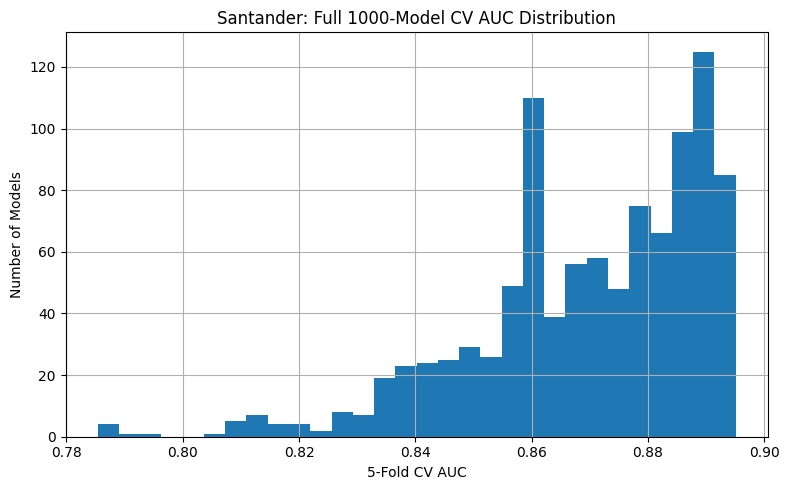

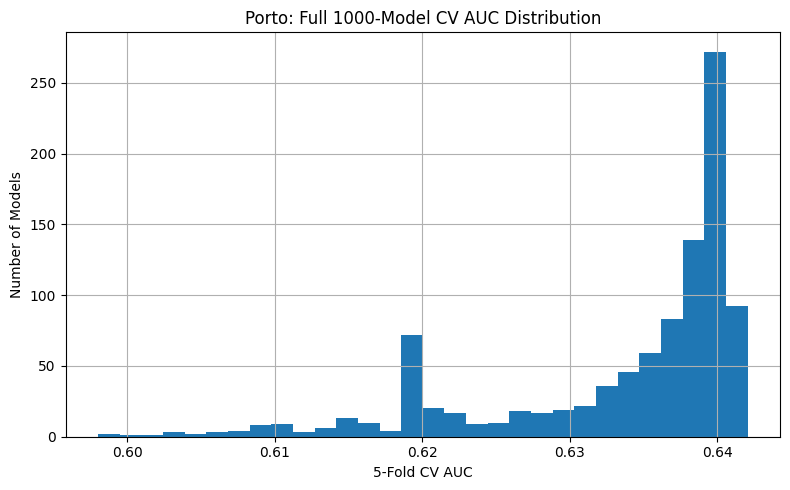

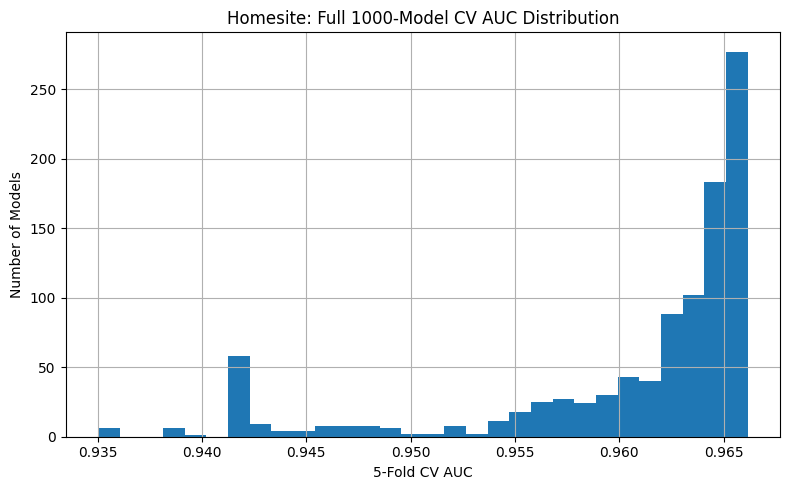

In [10]:
# PLOT FULL CV DISTRIBUTION BY COMPETITION
for competition in full_cv_df["competition"].unique():

    plot_df = full_cv_df[
        full_cv_df["competition"] == competition
    ]

    plt.figure(figsize=(8, 5))

    plt.hist(
        plot_df["cv_auc_mean"],
        bins=30
    )

    plt.xlabel("5-Fold CV AUC")
    plt.ylabel("Number of Models")
    plt.title(f"{competition.title()}: Full 1000-Model CV AUC Distribution")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 9. Leaderboard-Scored Dataset Summary

This section summarises the 300 leaderboard-scored models by competition and model family.

In [11]:
# SUMMARISE LEADERBOARD-SCORED DATASET BY COMPETITION
leaderboard_summary = (
    combined_df
    .groupby("competition")
    .agg(
        n_models=("model_id", "count"),
        mean_cv_auc=("cv_auc_mean", "mean"),
        mean_public_auc=("public_auc", "mean"),
        mean_private_auc=("private_auc", "mean"),
        mean_cv_private_gap=("cv_private_gap", "mean"),
        mean_abs_cv_private_gap=("abs_cv_private_gap", "mean"),
        mean_public_private_gap=("public_private_gap", "mean"),
        mean_abs_public_private_gap=("abs_public_private_gap", "mean")
    )
    .reset_index()
)

leaderboard_summary_path = (
    COMBINED_RESULTS_DIR /
    "leaderboard_scored_summary.csv"
)

leaderboard_summary.to_csv(
    leaderboard_summary_path,
    index=False
)

print("Saved leaderboard scored summary to:")
print(leaderboard_summary_path)

display(leaderboard_summary)

Saved leaderboard scored summary to:
../results/leaderboard_scored_summary.csv


,competition,n_models,mean_cv_auc,mean_public_auc,mean_private_auc,mean_cv_private_gap,mean_abs_cv_private_gap,mean_public_private_gap,mean_abs_public_private_gap
0,homesite,100,0.955840,0.956981,0.956401,-0.000562,0.000573,0.000580,0.000585
1,porto,100,0.626901,0.625845,0.627521,-0.000619,0.000999,-0.001676,0.001924
2,santander,100,0.858434,0.858785,0.855992,0.002442,0.003576,0.002793,0.002799


In [12]:
# SUMMARISE LEADERBOARD-SCORED DATASET BY MODEL FAMILY
leaderboard_family_summary = (
    combined_df
    .groupby("model_family")
    .agg(
        n_models=("model_id", "count"),
        mean_cv_auc=("cv_auc_mean", "mean"),
        mean_public_auc=("public_auc", "mean"),
        mean_private_auc=("private_auc", "mean"),
        mean_cv_private_gap=("cv_private_gap", "mean"),
        mean_abs_cv_private_gap=("abs_cv_private_gap", "mean"),
        mean_public_private_gap=("public_private_gap", "mean"),
        mean_abs_public_private_gap=("abs_public_private_gap", "mean")
    )
    .reset_index()
    .sort_values("mean_private_auc", ascending=False)
)

leaderboard_family_summary_path = (
    COMBINED_RESULTS_DIR /
    "leaderboard_scored_summary_by_family.csv"
)

leaderboard_family_summary.to_csv(
    leaderboard_family_summary_path,
    index=False
)

print("Saved leaderboard scored summary by family to:")
print(leaderboard_family_summary_path)

display(leaderboard_family_summary)

Saved leaderboard scored summary by family to:
../results/leaderboard_scored_summary_by_family.csv


,model_family,n_models,mean_cv_auc,mean_public_auc,mean_private_auc,mean_cv_private_gap,mean_abs_cv_private_gap,mean_public_private_gap,mean_abs_public_private_gap
4,random_forest,22,0.831196,0.831013,0.830360,0.000836,0.001596,0.000653,0.001622
0,catboost,60,0.819092,0.818594,0.818111,0.000981,0.001685,0.000483,0.001858
5,xgboost,75,0.816958,0.817055,0.816112,0.000847,0.001656,0.000944,0.001935
2,lightgbm,75,0.816431,0.816590,0.815721,0.000710,0.001687,0.000869,0.002038
3,logistic_regression,45,0.803305,0.804911,0.805212,-0.001908,0.001908,-0.000301,0.001143
1,extra_trees,23,0.784031,0.783426,0.783253,0.000778,0.001832,0.000173,0.001483


## 10. Correlation Analysis

This section measures how strongly cross-validation AUC and public leaderboard AUC correlate with private leaderboard AUC.

Both Pearson and Spearman correlations are computed overall, by competition, and by model family.

In [13]:
# COMPUTE CORRELATIONS
correlation_records = []

groups = [("overall", "all", combined_df)]

for competition, group_df in combined_df.groupby("competition"):
    groups.append(("competition", competition, group_df))

for model_family, group_df in combined_df.groupby("model_family"):
    groups.append(("model_family", model_family, group_df))

for group_type, group_name, group_df in groups:

    if len(group_df) < 3:
        continue

    cv_private_pearson = pearsonr(
        group_df["cv_auc_mean"],
        group_df["private_auc"]
    )[0]

    cv_private_spearman = spearmanr(
        group_df["cv_auc_mean"],
        group_df["private_auc"]
    )[0]

    public_private_pearson = pearsonr(
        group_df["public_auc"],
        group_df["private_auc"]
    )[0]

    public_private_spearman = spearmanr(
        group_df["public_auc"],
        group_df["private_auc"]
    )[0]

    correlation_records.append({
        "group_type": group_type,
        "group_name": group_name,
        "n_models": len(group_df),
        "cv_private_pearson": cv_private_pearson,
        "cv_private_spearman": cv_private_spearman,
        "public_private_pearson": public_private_pearson,
        "public_private_spearman": public_private_spearman
    })

correlation_df = pd.DataFrame(correlation_records)

correlation_path = (
    COMBINED_RESULTS_DIR /
    "correlation_analysis.csv"
)

correlation_df.to_csv(
    correlation_path,
    index=False
)

print("Saved correlation analysis to:")
print(correlation_path)

display(correlation_df)

Saved correlation analysis to:
../results/correlation_analysis.csv


,group_type,group_name,n_models,cv_private_pearson,cv_private_spearman,public_private_pearson,public_private_spearman
0,overall,all,300,0.999849,0.998848,0.999919,0.999245
1,competition,homesite,100,0.999342,0.987109,0.999481,0.995439
2,competition,porto,100,0.996967,0.989533,0.997015,0.992010
3,competition,santander,100,0.995336,0.992252,0.999158,0.992158
4,model_family,catboost,60,0.999864,0.996568,0.999939,0.995735
5,model_family,extra_trees,23,0.999901,0.993083,0.999948,0.994071
6,model_family,lightgbm,75,0.999884,0.994459,0.999893,0.996202
7,model_family,logistic_regression,45,0.999847,0.993786,0.999995,0.999568
8,model_family,random_forest,22,0.999938,0.984190,0.999894,0.987292
9,model_family,xgboost,75,0.999870,0.993314,0.999903,0.995170


## 11. Score Relationship Visualisations

This section visualises the relationship between cross-validation, public leaderboard, and private leaderboard scores.

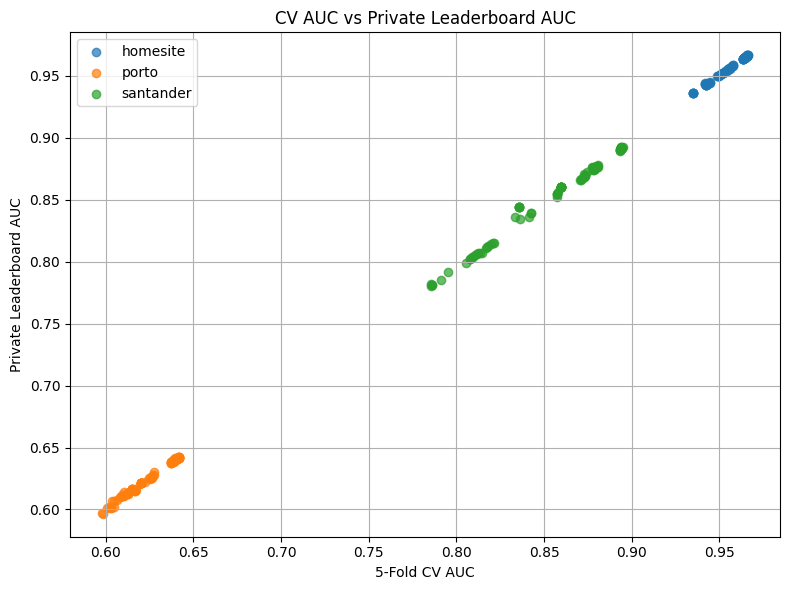

In [14]:
# SCATTER PLOT: CV AUC VS PRIVATE AUC
plt.figure(figsize=(8, 6))

for competition in combined_df["competition"].unique():

    plot_df = combined_df[
        combined_df["competition"] == competition
    ]

    plt.scatter(
        plot_df["cv_auc_mean"],
        plot_df["private_auc"],
        label=competition,
        alpha=0.7
    )

plt.xlabel("5-Fold CV AUC")
plt.ylabel("Private Leaderboard AUC")
plt.title("CV AUC vs Private Leaderboard AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

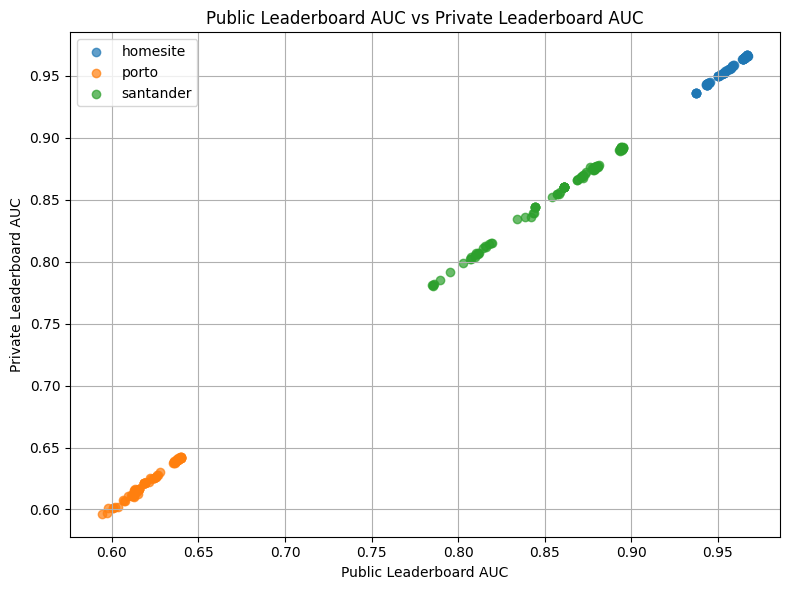

In [15]:
# SCATTER PLOT: PUBLIC AUC VS PRIVATE AUC
plt.figure(figsize=(8, 6))

for competition in combined_df["competition"].unique():

    plot_df = combined_df[
        combined_df["competition"] == competition
    ]

    plt.scatter(
        plot_df["public_auc"],
        plot_df["private_auc"],
        label=competition,
        alpha=0.7
    )

plt.xlabel("Public Leaderboard AUC")
plt.ylabel("Private Leaderboard AUC")
plt.title("Public Leaderboard AUC vs Private Leaderboard AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 12. Validation Gap Analysis

This section analyses systematic differences between:

- cross-validation AUC and private leaderboard AUC
- public leaderboard AUC and private leaderboard AUC

These gaps are used to estimate bias and uncertainty terms for Bayesian melding.

In [16]:
# GAP SUMMARY BY COMPETITION
gap_summary_competition = (
    combined_df
    .groupby("competition")
    .agg(
        n_models=("model_id", "count"),
        mean_cv_private_gap=("cv_private_gap", "mean"),
        std_cv_private_gap=("cv_private_gap", "std"),
        mean_abs_cv_private_gap=("abs_cv_private_gap", "mean"),
        median_abs_cv_private_gap=("abs_cv_private_gap", "median"),
        mean_public_private_gap=("public_private_gap", "mean"),
        std_public_private_gap=("public_private_gap", "std"),
        mean_abs_public_private_gap=("abs_public_private_gap", "mean"),
        median_abs_public_private_gap=("abs_public_private_gap", "median")
    )
    .reset_index()
)

gap_summary_competition_path = (
    COMBINED_RESULTS_DIR /
    "gap_summary_by_competition.csv"
)

gap_summary_competition.to_csv(
    gap_summary_competition_path,
    index=False
)

print("Saved gap summary by competition to:")
print(gap_summary_competition_path)

display(gap_summary_competition)

Saved gap summary by competition to:
../results/gap_summary_by_competition.csv


,competition,n_models,mean_cv_private_gap,std_cv_private_gap,mean_abs_cv_private_gap,median_abs_cv_private_gap,mean_public_private_gap,std_public_private_gap,mean_abs_public_private_gap,median_abs_public_private_gap
0,homesite,100,-0.000562,0.000392,0.000573,0.000483,0.000580,0.000334,0.000585,0.000525
1,porto,100,-0.000619,0.001075,0.000999,0.000845,-0.001676,0.001242,0.001924,0.002132
2,santander,100,0.002442,0.003249,0.003576,0.003230,0.002793,0.001437,0.002799,0.002975


In [17]:
# GAP SUMMARY BY MODEL FAMILY
gap_summary_family = (
    combined_df
    .groupby("model_family")
    .agg(
        n_models=("model_id", "count"),
        mean_cv_private_gap=("cv_private_gap", "mean"),
        std_cv_private_gap=("cv_private_gap", "std"),
        mean_abs_cv_private_gap=("abs_cv_private_gap", "mean"),
        median_abs_cv_private_gap=("abs_cv_private_gap", "median"),
        mean_public_private_gap=("public_private_gap", "mean"),
        std_public_private_gap=("public_private_gap", "std"),
        mean_abs_public_private_gap=("abs_public_private_gap", "mean"),
        median_abs_public_private_gap=("abs_public_private_gap", "median")
    )
    .reset_index()
    .sort_values("mean_abs_cv_private_gap")
)

gap_summary_family_path = (
    COMBINED_RESULTS_DIR /
    "gap_summary_by_model_family.csv"
)

gap_summary_family.to_csv(
    gap_summary_family_path,
    index=False
)

print("Saved gap summary by model family to:")
print(gap_summary_family_path)

display(gap_summary_family)

Saved gap summary by model family to:
../results/gap_summary_by_model_family.csv


,model_family,n_models,mean_cv_private_gap,std_cv_private_gap,mean_abs_cv_private_gap,median_abs_cv_private_gap,mean_public_private_gap,std_public_private_gap,mean_abs_public_private_gap,median_abs_public_private_gap
4,random_forest,22,0.000836,0.001804,0.001596,0.001149,0.000653,0.002342,0.001622,0.000445
5,xgboost,75,0.000847,0.002319,0.001656,0.000656,0.000944,0.002184,0.001935,0.002095
0,catboost,60,0.000981,0.002337,0.001685,0.000706,0.000483,0.002080,0.001858,0.002067
2,lightgbm,75,0.000710,0.002219,0.001687,0.000900,0.000869,0.002372,0.002038,0.002210
1,extra_trees,23,0.000778,0.002036,0.001832,0.001719,0.000173,0.001924,0.001483,0.001620
3,logistic_regression,45,-0.001908,0.002406,0.001908,0.001147,-0.000301,0.001430,0.001143,0.000700


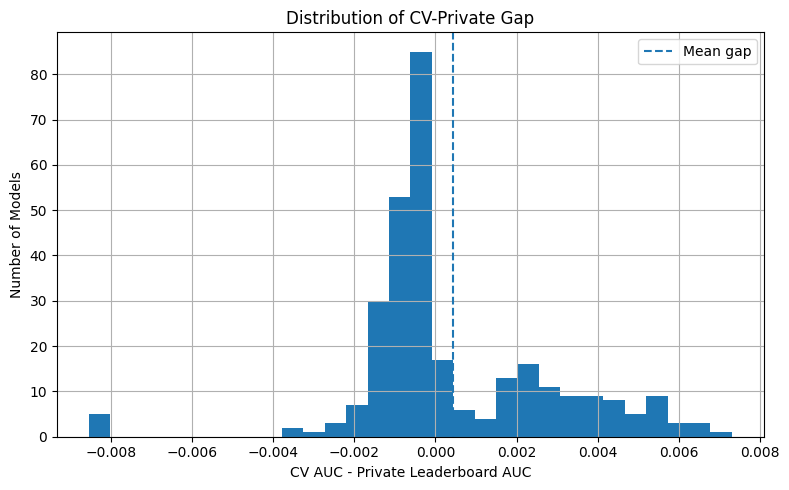

In [18]:
# HISTOGRAM: CV-PRIVATE GAP
plt.figure(figsize=(8, 5))

plt.hist(
    combined_df["cv_private_gap"],
    bins=30
)

plt.axvline(
    combined_df["cv_private_gap"].mean(),
    linestyle="--",
    label="Mean gap"
)

plt.xlabel("CV AUC - Private Leaderboard AUC")
plt.ylabel("Number of Models")
plt.title("Distribution of CV-Private Gap")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

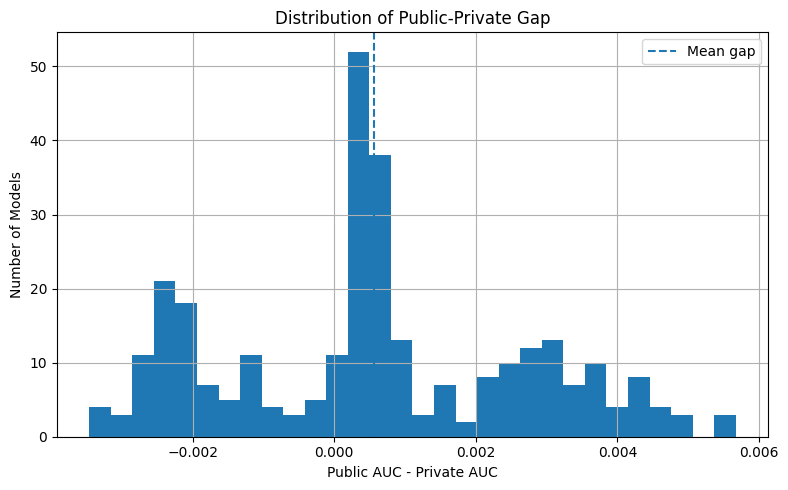

In [19]:
# HISTOGRAM: PUBLIC-PRIVATE GAP
plt.figure(figsize=(8, 5))

plt.hist(
    combined_df["public_private_gap"],
    bins=30
)

plt.axvline(
    combined_df["public_private_gap"].mean(),
    linestyle="--",
    label="Mean gap"
)

plt.xlabel("Public AUC - Private AUC")
plt.ylabel("Number of Models")
plt.title("Distribution of Public-Private Gap")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

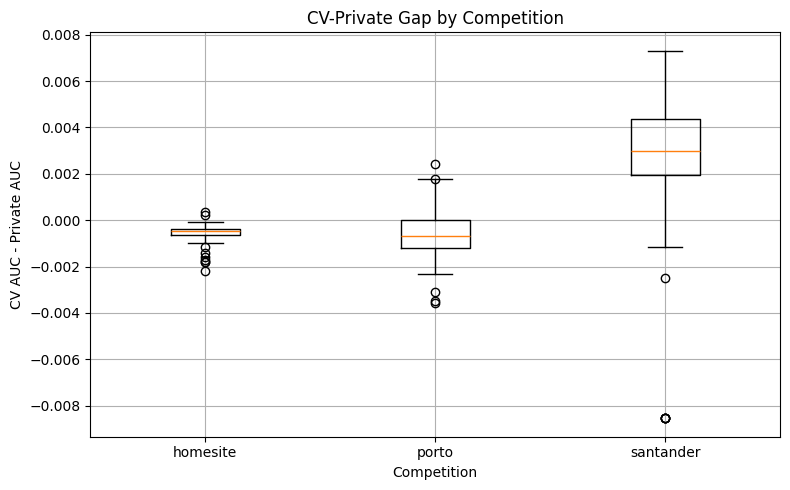

In [20]:
# BOXPLOT: CV-PRIVATE GAP BY COMPETITION
competitions = sorted(combined_df["competition"].unique())

boxplot_data = [
    combined_df[
        combined_df["competition"] == competition
    ]["cv_private_gap"]
    for competition in competitions
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    boxplot_data,
    labels=competitions
)

plt.xlabel("Competition")
plt.ylabel("CV AUC - Private AUC")
plt.title("CV-Private Gap by Competition")
plt.grid(True)
plt.tight_layout()
plt.show()

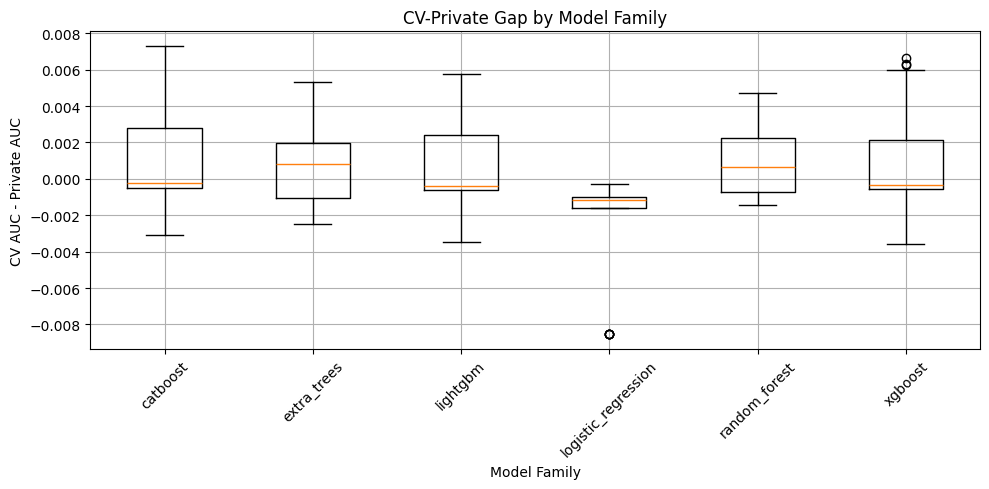

In [21]:
# BOXPLOT: CV-PRIVATE GAP BY MODEL FAMILY
model_families = sorted(combined_df["model_family"].unique())

boxplot_data = [
    combined_df[
        combined_df["model_family"] == family
    ]["cv_private_gap"]
    for family in model_families
]

plt.figure(figsize=(10, 5))

plt.boxplot(
    boxplot_data,
    labels=model_families
)

plt.xlabel("Model Family")
plt.ylabel("CV AUC - Private AUC")
plt.title("CV-Private Gap by Model Family")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## 13. Bayesian Melding Model

This section applies a Bayesian melding-style fusion approach.

Cross-validation, public leaderboard, and private leaderboard scores are treated as noisy observations of latent true model performance. Cross-validation and public leaderboard scores are bias-corrected using their empirical mean gaps relative to private leaderboard performance.

The final posterior estimate is computed using inverse-variance weighting.

In [22]:
# ESTIMATE GLOBAL BIAS TERMS
b_cv = combined_df["cv_private_gap"].mean()
b_public = combined_df["public_private_gap"].mean()

# ESTIMATE NOISE TERMS
sigma_cv = combined_df["cv_private_gap"].std()
sigma_public = combined_df["public_private_gap"].std()

# PRIVATE LEADERBOARD IS TREATED AS CLOSEST OBSERVED PROXY TO TRUE PERFORMANCE
sigma_private = min(
    sigma_cv,
    sigma_public
) / 2

print("Estimated CV bias:", b_cv)
print("Estimated public leaderboard bias:", b_public)

print("\nEstimated sigma CV:", sigma_cv)
print("Estimated sigma public:", sigma_public)
print("Assigned sigma private:", sigma_private)

Estimated CV bias: 0.0004203976205165046
Estimated public leaderboard bias: 0.0005656999999999802

Estimated sigma CV: 0.0024456801360513043
Estimated sigma public: 0.0021378491543345185
Assigned sigma private: 0.0010689245771672593


In [23]:
# APPLY BAYESIAN MELDING USING INVERSE-VARIANCE WEIGHTING
bayesian_df = combined_df.copy()

# BIAS-CORRECT OBSERVED SIGNALS
bayesian_df["cv_corrected"] = (
    bayesian_df["cv_auc_mean"]
    - b_cv
)

bayesian_df["public_corrected"] = (
    bayesian_df["public_auc"]
    - b_public
)

bayesian_df["private_corrected"] = (
    bayesian_df["private_auc"]
)

# COMPUTE SOURCE WEIGHTS
weight_cv = 1 / (sigma_cv ** 2)
weight_public = 1 / (sigma_public ** 2)
weight_private = 1 / (sigma_private ** 2)

total_weight = (
    weight_cv
    + weight_public
    + weight_private
)

# POSTERIOR MEAN FOR TRUE PERFORMANCE
bayesian_df["posterior_true_performance"] = (
    (
        weight_cv * bayesian_df["cv_corrected"]
        + weight_public * bayesian_df["public_corrected"]
        + weight_private * bayesian_df["private_corrected"]
    )
    / total_weight
)

# POSTERIOR STANDARD DEVIATION
bayesian_df["posterior_uncertainty"] = np.sqrt(
    1 / total_weight
)

display(
    bayesian_df[
        [
            "competition",
            "model_id",
            "model_family",
            "cv_auc_mean",
            "public_auc",
            "private_auc",
            "posterior_true_performance",
            "posterior_uncertainty"
        ]
    ].head()
)

,competition,model_id,model_family,cv_auc_mean,public_auc,private_auc,posterior_true_performance,posterior_uncertainty
0,homesite,14,lightgbm,0.964553,0.96547,0.96502,0.964882,0.00089
1,homesite,21,lightgbm,0.965851,0.96696,0.96648,0.966326,0.00089
2,homesite,27,lightgbm,0.952139,0.95338,0.95257,0.952500,0.00089
3,homesite,36,lightgbm,0.965989,0.96708,0.96662,0.966462,0.00089
4,homesite,52,lightgbm,0.943983,0.94495,0.94447,0.944335,0.00089


In [24]:
# SAVE BAYESIAN MELDING OUTPUT
bayesian_output_path = (
    COMBINED_RESULTS_DIR /
    "combined_bayesian_melding_output.csv"
)

bayesian_df.to_csv(
    bayesian_output_path,
    index=False
)

print("Saved Bayesian melding output to:")
print(bayesian_output_path)

Saved Bayesian melding output to:
../results/combined_bayesian_melding_output.csv


## 14. Bayesian Melding Summary

This section summarises posterior true performance estimates by competition and model family.

In [25]:
# POSTERIOR SUMMARY BY COMPETITION
posterior_summary_competition = (
    bayesian_df
    .groupby("competition")
    .agg(
        n_models=("model_id", "count"),
        mean_posterior_performance=("posterior_true_performance", "mean"),
        std_posterior_performance=("posterior_true_performance", "std"),
        mean_posterior_uncertainty=("posterior_uncertainty", "mean"),
        mean_private_auc=("private_auc", "mean"),
        mean_cv_auc=("cv_auc_mean", "mean"),
        mean_public_auc=("public_auc", "mean"),
        mean_abs_cv_private_gap=("abs_cv_private_gap", "mean"),
        mean_abs_public_private_gap=("abs_public_private_gap", "mean")
    )
    .reset_index()
)

posterior_summary_competition_path = (
    COMBINED_RESULTS_DIR /
    "posterior_summary_by_competition.csv"
)

posterior_summary_competition.to_csv(
    posterior_summary_competition_path,
    index=False
)

print("Saved posterior summary by competition to:")
print(posterior_summary_competition_path)

display(posterior_summary_competition)

Saved posterior summary by competition to:
../results/posterior_summary_by_competition.csv


,competition,n_models,mean_posterior_performance,std_posterior_performance,mean_posterior_uncertainty,mean_private_auc,mean_cv_auc,mean_public_auc,mean_abs_cv_private_gap,mean_abs_public_private_gap
0,homesite,100,0.956274,0.009911,0.00089,0.956401,0.955840,0.956981,0.000573,0.000585
1,porto,100,0.626994,0.013658,0.00089,0.627521,0.626901,0.625845,0.000999,0.001924
2,santander,100,0.856646,0.033072,0.00089,0.855992,0.858434,0.858785,0.003576,0.002799


In [26]:
# POSTERIOR SUMMARY BY MODEL FAMILY
posterior_summary_family = (
    bayesian_df
    .groupby("model_family")
    .agg(
        n_models=("model_id", "count"),
        mean_posterior_performance=("posterior_true_performance", "mean"),
        std_posterior_performance=("posterior_true_performance", "std"),
        mean_posterior_uncertainty=("posterior_uncertainty", "mean"),
        mean_private_auc=("private_auc", "mean"),
        mean_cv_auc=("cv_auc_mean", "mean"),
        mean_public_auc=("public_auc", "mean"),
        mean_abs_cv_private_gap=("abs_cv_private_gap", "mean"),
        mean_abs_public_private_gap=("abs_public_private_gap", "mean")
    )
    .reset_index()
    .sort_values("mean_posterior_performance", ascending=False)
)

posterior_summary_family_path = (
    COMBINED_RESULTS_DIR /
    "posterior_summary_by_model_family.csv"
)

posterior_summary_family.to_csv(
    posterior_summary_family_path,
    index=False
)

print("Saved posterior summary by model family to:")
print(posterior_summary_family_path)

display(posterior_summary_family)

Saved posterior summary by model family to:
../results/posterior_summary_by_model_family.csv


,model_family,n_models,mean_posterior_performance,std_posterior_performance,mean_posterior_uncertainty,mean_private_auc,mean_cv_auc,mean_public_auc,mean_abs_cv_private_gap,mean_abs_public_private_gap
4,random_forest,22,0.830430,0.146991,0.00089,0.830360,0.831196,0.831013,0.001596,0.001622
0,catboost,60,0.818171,0.139065,0.00089,0.818111,0.819092,0.818594,0.001685,0.001858
5,xgboost,75,0.816234,0.141208,0.00089,0.816112,0.816958,0.817055,0.001656,0.001935
2,lightgbm,75,0.815812,0.140976,0.00089,0.815721,0.816431,0.816590,0.001687,0.002038
3,logistic_regression,45,0.804753,0.137481,0.00089,0.805212,0.803305,0.804911,0.001908,0.001143
1,extra_trees,23,0.783232,0.140422,0.00089,0.783253,0.784031,0.783426,0.001832,0.001483


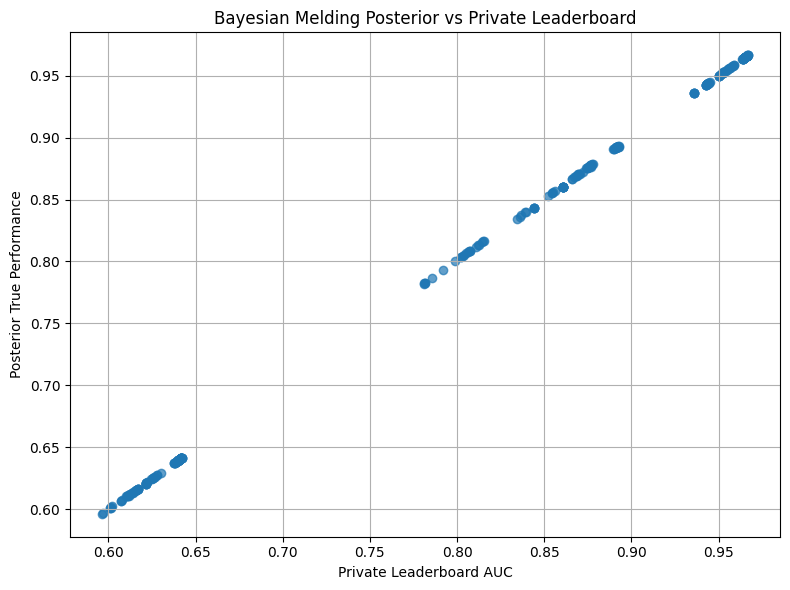

In [27]:
# PLOT POSTERIOR TRUE PERFORMANCE VS PRIVATE AUC
plt.figure(figsize=(8, 6))

plt.scatter(
    bayesian_df["private_auc"],
    bayesian_df["posterior_true_performance"],
    alpha=0.7
)

plt.xlabel("Private Leaderboard AUC")
plt.ylabel("Posterior True Performance")
plt.title("Bayesian Melding Posterior vs Private Leaderboard")
plt.grid(True)
plt.tight_layout()
plt.show()

## 15. Within-Competition Centered Correlation Analysis

This section computes correlations after centering scores within each competition.

This reduces the effect of different baseline difficulty levels across competitions and focuses on within-competition ranking reliability.

In [29]:
# WITHIN-COMPETITION CENTERED CORRELATION ANALYSIS
centered_df = combined_df.copy()

centered_df["cv_auc_centered"] = (
    centered_df["cv_auc_mean"]
    - centered_df.groupby("competition")["cv_auc_mean"].transform("mean")
)

centered_df["public_auc_centered"] = (
    centered_df["public_auc"]
    - centered_df.groupby("competition")["public_auc"].transform("mean")
)

centered_df["private_auc_centered"] = (
    centered_df["private_auc"]
    - centered_df.groupby("competition")["private_auc"].transform("mean")
)

centered_cv_private_pearson = pearsonr(
    centered_df["cv_auc_centered"],
    centered_df["private_auc_centered"]
)[0]

centered_cv_private_spearman = spearmanr(
    centered_df["cv_auc_centered"],
    centered_df["private_auc_centered"]
)[0]

centered_public_private_pearson = pearsonr(
    centered_df["public_auc_centered"],
    centered_df["private_auc_centered"]
)[0]

centered_public_private_spearman = spearmanr(
    centered_df["public_auc_centered"],
    centered_df["private_auc_centered"]
)[0]

centered_correlation_df = pd.DataFrame([
    {
        "analysis": "within_competition_centered",
        "n_models": len(centered_df),
        "cv_private_pearson": centered_cv_private_pearson,
        "cv_private_spearman": centered_cv_private_spearman,
        "public_private_pearson": centered_public_private_pearson,
        "public_private_spearman": centered_public_private_spearman
    }
])

centered_correlation_path = (
    COMBINED_RESULTS_DIR /
    "centered_correlation_analysis.csv"
)

centered_correlation_df.to_csv(
    centered_correlation_path,
    index=False
)

display(centered_correlation_df)

print("Saved centered correlation analysis to:")
print(centered_correlation_path)

,analysis,n_models,cv_private_pearson,cv_private_spearman,public_private_pearson,public_private_spearman
0,within_competition_centered,300,0.995804,0.994294,0.998821,0.99646


Saved centered correlation analysis to:
../results/centered_correlation_analysis.csv


## 16. Final Report Figures

This section generates final figures used in the research report.

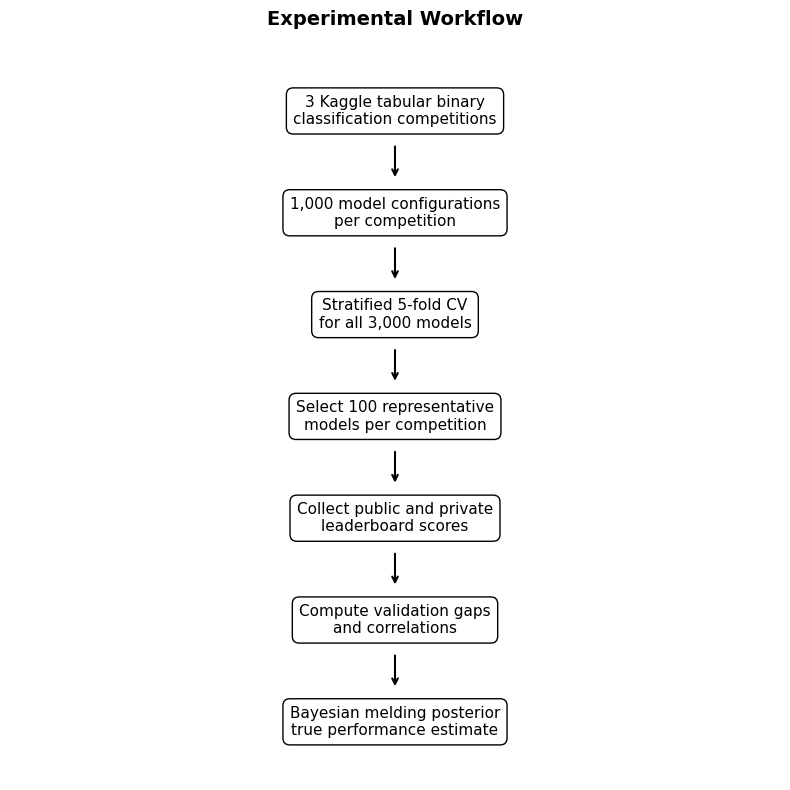

In [30]:
# FIGURE 1: EXPERIMENTAL WORKFLOW DIAGRAM
fig, ax = plt.subplots(figsize=(8, 8))

ax.axis("off")

steps = [
    "3 Kaggle tabular binary\nclassification competitions",
    "1,000 model configurations\nper competition",
    "Stratified 5-fold CV\nfor all 3,000 models",
    "Select 100 representative\nmodels per competition",
    "Collect public and private\nleaderboard scores",
    "Compute validation gaps\nand correlations",
    "Bayesian melding posterior\ntrue performance estimate"
]

y_positions = np.linspace(0.92, 0.08, len(steps))

for i, (step, y) in enumerate(zip(steps, y_positions)):

    ax.text(
        0.5,
        y,
        step,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.45",
            edgecolor="black",
            facecolor="white"
        )
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(0.5, y_positions[i + 1] + 0.045),
            xytext=(0.5, y - 0.045),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5
            )
        )

plt.title(
    "Experimental Workflow",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

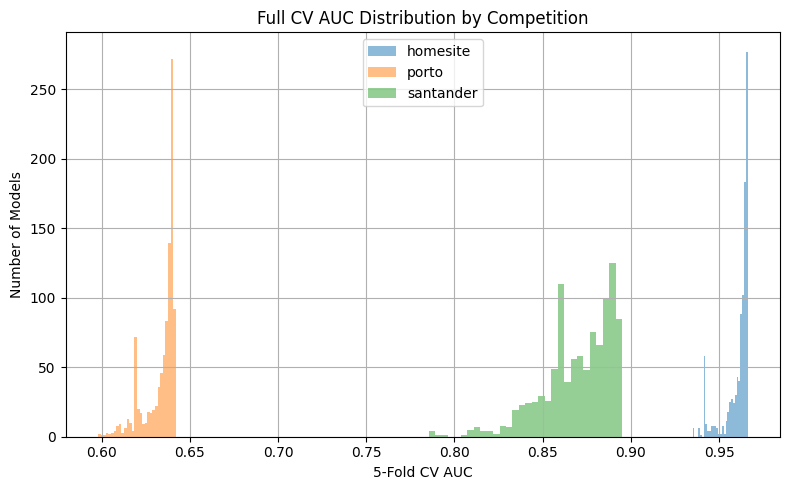

In [31]:
# FIGURE 2: FULL CV AUC DISTRIBUTION BY COMPETITION
competitions = ["homesite", "porto", "santander"]

plt.figure(figsize=(8, 5))

for competition in competitions:
    plot_df = full_cv_df[
        full_cv_df["competition"] == competition
    ]

    plt.hist(
        plot_df["cv_auc_mean"],
        bins=30,
        alpha=0.5,
        label=competition
    )

plt.xlabel("5-Fold CV AUC")
plt.ylabel("Number of Models")
plt.title("Full CV AUC Distribution by Competition")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 17. Final Output File Check

This section verifies that all expected final research output files exist in `results/combined/`.

In [28]:
# FINAL OUTPUT FILE CHECK
output_files = [
    COMBINED_RESULTS_DIR / "combined_final_research_dataset.csv",
    COMBINED_RESULTS_DIR / "combined_full_cv_population_dataset.csv",
    COMBINED_RESULTS_DIR / "full_cv_population_summary.csv",
    COMBINED_RESULTS_DIR / "leaderboard_scored_summary.csv",
    COMBINED_RESULTS_DIR / "leaderboard_scored_summary_by_family.csv",
    COMBINED_RESULTS_DIR / "correlation_analysis.csv",
    COMBINED_RESULTS_DIR / "gap_summary_by_competition.csv",
    COMBINED_RESULTS_DIR / "gap_summary_by_model_family.csv",
    COMBINED_RESULTS_DIR / "combined_bayesian_melding_output.csv",
    COMBINED_RESULTS_DIR / "posterior_summary_by_competition.csv",
    COMBINED_RESULTS_DIR / "posterior_summary_by_model_family.csv",
    COMBINED_RESULTS_DIR / "centered_correlation_analysis.csv",
]

for file_path in output_files:
    status = "FOUND" if file_path.exists() else "MISSING"
    print(f"{status}: {file_path}")

FOUND: ../results/combined_final_research_dataset.csv
FOUND: ../results/combined_full_cv_population_dataset.csv
FOUND: ../results/full_cv_population_summary.csv
FOUND: ../results/leaderboard_scored_summary.csv
FOUND: ../results/leaderboard_scored_summary_by_family.csv
FOUND: ../results/correlation_analysis.csv
FOUND: ../results/gap_summary_by_competition.csv
FOUND: ../results/gap_summary_by_model_family.csv
FOUND: ../results/combined_bayesian_melding_output.csv
FOUND: ../results/posterior_summary_by_competition.csv
FOUND: ../results/posterior_summary_by_model_family.csv


## Summary

This notebook produces the final combined research outputs used in the report.

It combines the three competition-level datasets, analyses cross-validation and leaderboard reliability, estimates validation bias and uncertainty, applies Bayesian melding, and exports final summary tables and figures.

The outputs from this notebook form the basis of the final research discussion and publication draft.